# Supplementary Figure 1 — Response convergence during acquisition

Supplementary Figure 1 (response convergence during acquisition), built from
`data/processed/`. Not in the submitted manuscript; kept because it justifies the
24/32 acquisition criterion.

**Idea.** Each trial of the two-start-two-choice (2S2C) task affords **four**
possible turn sequences (L/R at two successive choice points): `LL, LR, RL,
RR`. For a given goal, exactly **two** of them are goal-directed — one per
start arm. Tracking how rats' responses converge onto these two sequences,
*before* they discriminate which one belongs to which start arm, separates
two stages of learning.

**Two series** (median across rats, aligned so session 0 = criterion/final
acquisition session):
- **One of two correct routes** (solid blue): proportion of trials whose
  executed route (`actual_route`) is one of the session's two goal-directed
  routes — regardless of start arm.
- **Traditional accuracy** (dashed grey): proportion of trials whose executed
  route matches the correct route for *that trial's* start arm
  (`actual_route == correct_route`).

By construction the traditional series is a strict subset of the
one-of-two series, so the two lines are properly nested. Both are
**response-sequence** measures (executed route), which is the right framing
for this figure; this differs marginally (~2%) from the `errors == 0`
"correct" definition used in the main figures.

**Chance lines.** 0.50 = picking one of two correct routes at random from
four; 0.25 = picking the single trial-correct route from four.

**Cohort.** All 47 rats in the paper, from `config/subjects.yaml`
(`supp_fig1`): the 41 main-cohort rats (`PI+VC` = fixed 2nd; `PI`; `VC`) and
the 6 `PI+VC_f1` (fixed 1st, "F1") rats of Figure 2G. Each rat is right-aligned to its final
acquisition session, so session 0 = the criterion session.

**N.** The 47 rats of the manuscript cohort.


## Preamble — imports, paths, style


In [1]:
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yaml

PROJECT_ROOT = Path.cwd().parents[1]   # figures/notebooks/ -> repo root
CONFIG = PROJECT_ROOT / 'config'
DATA = PROJECT_ROOT / 'data' / 'processed'
FIG_OUT = PROJECT_ROOT / 'figures' / 'images'
FIG_OUT.mkdir(exist_ok=True)

pd.set_option('display.max_columns', None, 'display.width', 200)


In [2]:
# Series colours (from legacy supp_figure_1.py): blue = one-of-two,
# grey = traditional accuracy. Light variants for individual-rat scatter.
COLOR_OOT,  COLOR_OOT_LIGHT = '#03567C', '#5AA1BC'
COLOR_ACC,  COLOR_ACC_LIGHT = '#777777', '#BBBBBB'
CHANCE_COLOR = '#BBBBBB'

# Typography (Cell floor; Wiley/Hippocampus sets no numeric minimum): Helvetica, 6-8 pt body, vector PDF with editable text.
plt.rcParams.update({
    'font.family': 'Helvetica',
    'font.size': 8,
    'axes.labelsize': 7,
    'axes.titlesize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'axes.linewidth': 0.75,
    'xtick.major.width': 0.75,
    'ytick.major.width': 0.75,
    'lines.linewidth': 0.75,
    'patch.linewidth': 0.75,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 200,
    'savefig.dpi': 300,
})


## Load cohort and parquets

Cohort = all 47 paper rats from `config/subjects.yaml` (`supp_fig1`),
labelled by `subjects.training_group`.


In [3]:
BEHAVIORAL_GROUPS = ['PI+VC', 'PI+VC_f1', 'PI', 'VC']

# Manuscript cohort: all 47 rats in the paper (config/subjects.yaml, key supp_fig1).
_cohort_yaml = yaml.safe_load((CONFIG / 'subjects.yaml').read_text())
cohort_ids = {sid for ids in _cohort_yaml['supp_fig1'].values() for sid in ids}

subjects = pd.read_parquet(DATA / 'subjects.parquet')
sessions = pd.read_parquet(DATA / 'sessions.parquet')
trials   = pd.read_parquet(DATA / 'trials.parquet')

cohort = subjects[subjects['subject_id'].isin(cohort_ids)].copy()
assert set(cohort['training_group'].astype(str)) <= set(BEHAVIORAL_GROUPS)

acq_sessions = (sessions[sessions['subject_id'].isin(cohort_ids)
                         & (sessions['session_experiment_phase'] == 'Acquisition')]
                .sort_values(['subject_id', 'session_id']).copy())
# Right-align to the final acquisition session: rank_desc 0 = criterion/final.
acq_sessions['rank_desc'] = acq_sessions.groupby('subject_id', observed=True).cumcount(ascending=False)

n_rats = acq_sessions['subject_id'].nunique()
print('Cohort (Supp. Fig. 1 — response convergence):')
print(cohort.groupby('training_group', observed=True)['subject_id'].nunique()
      .reindex(BEHAVIORAL_GROUPS).to_string())
print(f'  total = {n_rats} rats with acquisition data')
assert n_rats == 47, n_rats


Cohort (Supp. Fig. 1 — response convergence):
training_group
PI+VC       17
PI+VC_f1     6
PI          12
VC          12
  total = 47 rats with acquisition data


## Per-session convergence series

For each acquisition session:
- the **two goal-directed routes** = the (up to two) most frequent
  `correct_route` values in that session. One session has three distinct
  correct routes (a logging quirk); the top-two-by-frequency rule mirrors the
  legacy implementation and handles it.
- **one_of_two** = fraction of trials with `actual_route` in that set.
- **traditional** = fraction of trials with `actual_route == correct_route`.


In [4]:
at = trials.merge(acq_sessions[['session_id', 'subject_id', 'rank_desc']],
                  on='session_id', how='inner').copy()
at = at.dropna(subset=['actual_route', 'correct_route'])

recs = []
for sid, g in at.groupby('session_id', sort=False):
    correct_set = set(g['correct_route'].value_counts().index[:2])   # top-2 routes
    one_of_two  = g['actual_route'].isin(correct_set).mean()
    traditional = (g['actual_route'] == g['correct_route']).mean()
    recs.append((sid, one_of_two, traditional, len(correct_set)))

conv = (pd.DataFrame(recs, columns=['session_id', 'one_of_two', 'traditional', 'n_routes'])
        .merge(acq_sessions[['session_id', 'subject_id', 'rank_desc']], on='session_id'))

print(f'{conv["session_id"].nunique()} sessions across {conv["subject_id"].nunique()} rats.')
print(f'Sessions with !=2 goal-directed routes: '
      f'{(conv["n_routes"] != 2).sum()} (handled by top-2 rule).')
print()
med = conv.groupby('rank_desc')[['one_of_two', 'traditional']].median()
nrat = conv.groupby('rank_desc')['subject_id'].nunique()
print('Median series + rats per sessions-to-criterion (0 = criterion):')
print(pd.concat([med.round(3), nrat.rename('n_rats')], axis=1).head(12).to_string())


324 sessions across 47 rats.
Sessions with !=2 goal-directed routes: 0 (handled by top-2 rule).

Median series + rats per sessions-to-criterion (0 = criterion):
           one_of_two  traditional  n_rats
rank_desc                                 
0               1.000        0.906      47
1               1.000        0.833      47
2               0.966        0.714      47
3               0.895        0.577      43
4               0.798        0.491      42
5               0.781        0.444      31
6               0.594        0.375      23
7               0.643        0.317      14
8               0.462        0.222       9
9               0.500        0.250       5
10              0.303        0.087       4
11              0.513        0.269       2


## Panel — response convergence

Median lines for each series, individual rats as semi-transparent points, and
dotted chance lines at 0.50 and 0.25. The x-axis is capped at the largest
sessions-to-criterion where at least `min_n` rats still contribute (the
median is uninformative beyond that); points/medians outside the window are
not drawn but remain in the data.


Display window: sessions-to-criterion 0..7 (>= 10 rats).
Saved: figures/images/supp_figure1.svg


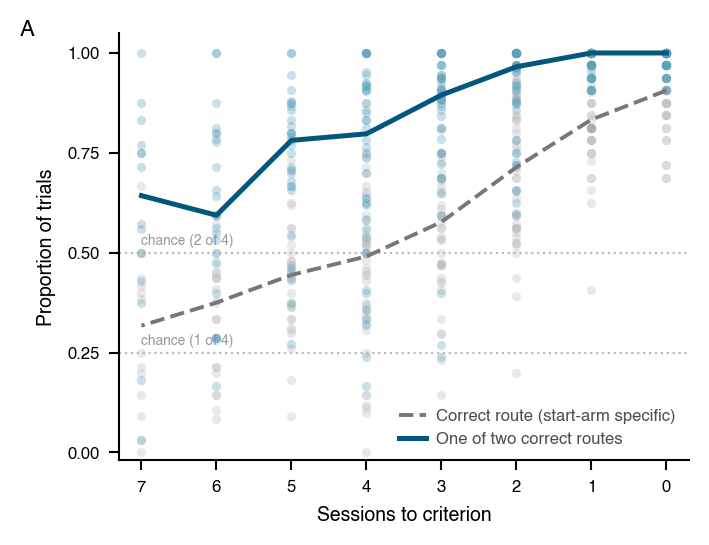

In [5]:
# Display window: largest sessions-to-criterion with >= min_n rats.
_nrat = conv.groupby('rank_desc')['subject_id'].nunique()
DEFAULT_MIN_N = 10
PANEL_MAX_SESSION = int(_nrat[_nrat >= DEFAULT_MIN_N].index.max())
print(f'Display window: sessions-to-criterion 0..{PANEL_MAX_SESSION} '
      f'(>= {DEFAULT_MIN_N} rats).')

def panel_convergence(ax, *, conv=conv, max_session=None, min_n=DEFAULT_MIN_N,
                      oot_lw=1.8, acc_lw=1.4, scatter_s=11, scatter_alpha=0.32,
                      chance_lw=0.8, show_chance_labels=True,
                      ylim=(-0.02, 1.05), yticks=(0, 0.25, 0.5, 0.75, 1.0),
                      ylabel='Proportion of trials', xlabel='Sessions to criterion',
                      show_legend=True, legend_loc='lower right', legend_fontsize=6):
    'Supp Fig 1: response-convergence panel.'
    cap = PANEL_MAX_SESSION if max_session is None else max_session
    d = conv[conv['rank_desc'] <= cap]

    # Chance reference lines.
    for y, lab in [(0.50, 'chance (2 of 4)'), (0.25, 'chance (1 of 4)')]:
        ax.axhline(y, color=CHANCE_COLOR, ls=':', lw=chance_lw, zorder=1)
        if show_chance_labels:
            ax.text(cap, y + 0.012, lab, fontsize=5.0, color='#999999',
                    ha='left', va='bottom', clip_on=False)

    grp = d.groupby('rank_desc')
    nrat = grp['subject_id'].nunique()
    keep = nrat[nrat >= min_n].index

    # Series 2 (traditional) drawn first so blue sits on top.
    ax.scatter(d['rank_desc'], d['traditional'], s=scatter_s, color=COLOR_ACC_LIGHT,
               alpha=scatter_alpha, linewidths=0, zorder=2)
    med_acc = grp['traditional'].median().reindex(keep)
    ax.plot(med_acc.index, med_acc.values, color=COLOR_ACC, ls='--', lw=acc_lw,
            zorder=4, label='Correct route (start-arm specific)')

    ax.scatter(d['rank_desc'], d['one_of_two'], s=scatter_s, color=COLOR_OOT_LIGHT,
               alpha=scatter_alpha, linewidths=0, zorder=3)
    med_oot = grp['one_of_two'].median().reindex(keep)
    ax.plot(med_oot.index, med_oot.values, color=COLOR_OOT, ls='-', lw=oot_lw,
            zorder=5, label='One of two correct routes')

    ax.set_xlim(cap + 0.3, -0.3)        # criterion (0) on the right
    ax.set_xticks(range(0, cap + 1))
    ax.set_xlabel(xlabel)
    ax.set_ylim(*ylim)
    ax.set_yticks(list(yticks))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))
    ax.set_ylabel(ylabel)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if show_legend:
        leg = ax.legend(loc=legend_loc, frameon=False, fontsize=legend_fontsize,
                        handlelength=1.6, handletextpad=0.6, borderpad=0.3)
        for t in leg.get_texts():
            t.set_color('0.3')

fig, ax = plt.subplots(figsize=(3.5, 2.7))
panel_convergence(ax)
fig.text(0.01, 0.98, 'A', fontsize=8, fontweight='bold', va='top', ha='left')
fig.tight_layout()
fig.savefig(FIG_OUT / 'supp_figure1.svg', bbox_inches='tight')
print('Saved:', FIG_OUT / 'supp_figure1.svg')
plt.show()


## Descriptive summary — the convergence gap

Confirms the manuscript narrative: early in training the traditional series
hovers near single-route chance (0.25) while the one-of-two series is already
elevated toward two-route chance (0.50) and above — rats restrict to the two
goal-directed routes before discriminating which route fits which start arm.


In [6]:
summary = (conv.groupby('rank_desc')[['one_of_two', 'traditional']]
           .median().assign(gap=lambda d: d['one_of_two'] - d['traditional']))
print('Median one-of-two, traditional, and gap by sessions-to-criterion:')
print(summary.head(PANEL_MAX_SESSION + 1).round(3).to_string())
print()
far = summary.loc[(summary.index >= 4) & (summary.index <= PANEL_MAX_SESSION)]
if len(far):
    print(f'>= 4 sessions before criterion: median one-of-two stays '
          f'{far["one_of_two"].min():.2f}-{far["one_of_two"].max():.2f} while '
          f'traditional sits {far["traditional"].min():.2f}-{far["traditional"].max():.2f} '
          f'(near single-route chance 0.25).')


Median one-of-two, traditional, and gap by sessions-to-criterion:
           one_of_two  traditional    gap
rank_desc                                
0               1.000        0.906  0.094
1               1.000        0.833  0.167
2               0.966        0.714  0.251
3               0.895        0.577  0.318
4               0.798        0.491  0.307
5               0.781        0.444  0.337
6               0.594        0.375  0.219
7               0.643        0.317  0.326

>= 4 sessions before criterion: median one-of-two stays 0.59-0.80 while traditional sits 0.32-0.49 (near single-route chance 0.25).
